<a href="https://colab.research.google.com/github/vanditha18/NLP-Notebooks/blob/main/News_Text_Classification_using_BERT_Finetune.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Install packages

In [1]:
!which python

/usr/local/bin/python


In [ ]:
!pip install scikit-learn evaluate

In [ ]:
!pip install matplotlib

In [ ]:
!pip install pandas

In [ ]:
!pip install -U transformers

In [ ]:
!pip install torch

## Import Libraries

In [1]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
import numpy as np
import pandas as pd
import re
import evaluate
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from torch.utils.data import DataLoader
import torch
from torch.utils.data import Dataset

## Dataset and Dataloader

In [2]:
dataset_csv_path = "/content/news_classification.csv"
df = pd.read_csv(dataset_csv_path)
df.head(10)

,Text,Label
0,Budget to set scene for election\n \n Gordon B...,0
1,Army chiefs in regiments decision\n \n Militar...,0
2,Howard denies split over ID cards\n \n Michael...,0
3,Observers to monitor UK election\n \n Minister...,0
4,Kilroy names election seat target\n \n Ex-chat...,0
5,Donor attacks Blair-Brown 'feud'\n \n The repo...,0
6,Research fears over Kelly's views\n \n Scienti...,0
7,Chancellor rallies Labour voters\n \n Gordon B...,0
8,Fox attacks Blair's Tory 'lies'\n \n Tony Blai...,0
9,Tories unveil quango blitz plans\n \n Plans to...,0


## Dataset preparation

In [3]:
def clean_text(text):
    # Remove HTML tags
    text = re.compile('<.*?>').sub('', text)
    # Remove URL's
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'www\S+', '', text)
    # Remove punctuation
    text = re.sub(r'[^\w\s]', '', text)
    #Remove all extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [4]:
df['Text'] = df['Text'].apply(clean_text)

In [7]:
df[df['Text'].str.contains('Politics|Sport|Technology|Entertainment|Business', case=False, na=False)].sum()

,0
Text,Howard denies split over ID cards Michael Howa...
Label,1656


In [8]:
def remove_keywords(text):
    return re.sub(r'\b(\w*Politic\w*|\w*Sport\w*|\w*Technology\w*|\w*Entertainment\w*|\w*Business\w*|\w*game\w*)\b','[category]', text, flags=re.IGNORECASE)

df['Text'] = df['Text'].apply(remove_keywords)

df[df['Text'].str.contains('Politics|Sport|Technology|Entertainment|Business|game', case=False, na=False)]

,Text,Label


In [9]:
df.isna().sum()
#df['Document'] = df['Document'].dropna()

,0
Text,0
Label,0


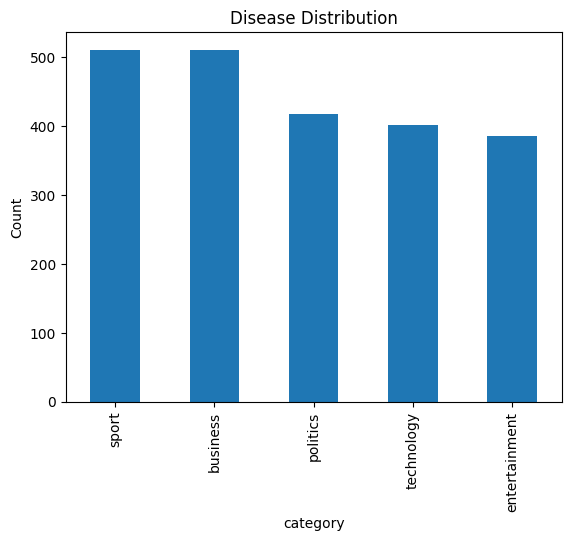

In [10]:
label_mapping = {0:'politics',1:'sport',2:'technology',3:'entertainment',4:'business'}
df['category'] = df['Label'].map(label_mapping)
df['category'].value_counts().plot(kind='bar')
plt.xlabel('category')
plt.ylabel('Count')
plt.title('Disease Distribution')
plt.show()

In [11]:
df.duplicated().sum()

np.int64(102)

In [12]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [13]:
X = df.iloc[:,0:1]
Y = np.array(df['Label'])

In [14]:
###Split data
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

In [15]:
X_train['Text']

,Text
177,Amnesty chief laments war failure The lack of ...
1058,PlayStation 3 processor unveiled The Cell proc...
381,Student inequality exposed Teenagers from well...
899,Ireland 1712 South Africa Ronan OGara scored a...
1447,Casino Royale is next Bond movie Casino Royale...
...,...
513,Unclear future for striker Baros Liverpool for...
1630,New Harry Potter tops book chart Harry Potter ...
308,Fido to be taken off vote lists The risk of pe...
1207,California sets fines for spyware The makers o...


In [16]:
y_train

array([0, 2, 0, ..., 0, 2, 4])

## Model training

In [17]:
### Load tokenizer
model_checkpoint = "bert-base-uncased" # @param ["bert-base-uncased", "bert-large-uncased", "distilbert-base-uncased", "roberta-base"]

tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [18]:
def tokenize_function(examples):
    return tokenizer(examples["Text"], truncation=True, padding='max_length', max_length=128)

X_train_tokenized = X_train.apply(lambda x: tokenize_function(x), axis=1)
X_test_tokenized = X_test.apply(lambda x: tokenize_function(x), axis=1)

In [19]:
text = 'UK election Ministers will invite international observers '

tokenized_text = tokenizer(text, return_tensors='pt')

for key, value in tokenized_text.items():
    print(f"{key}: {value}")

input_ids: tensor([[  101,  2866,  2602,  7767,  2097, 13260,  2248, 14009,   102]])
token_type_ids: tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0]])
attention_mask: tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1]])


In [20]:
import torch.nn as nn

class CustomBERTModel(nn.Module):
    def __init__(self, pretrained_model_name, num_labels, device):
        super(CustomBERTModel, self).__init__()
        self.bert = AutoModelForSequenceClassification.from_pretrained(pretrained_model_name, num_labels=num_labels)
        self.bert.to(device)
        self.dropout = nn.Dropout(0.3)

    def forward(self, input_ids, attention_mask, token_type_ids=None, labels=None):
        # Pass labels to the underlying BERT model
        output = self.bert(input_ids=input_ids, attention_mask=attention_mask, token_type_ids=token_type_ids, labels=labels)
        if self.training:
          output.logits = self.dropout(output.logits)
        return output

# Initialize the custom model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CustomBERTModel(model_checkpoint, num_labels=5, device=device)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [21]:
from transformers import TrainingArguments
from transformers import EarlyStoppingCallback

# Define training arguments
training_args = TrainingArguments(
    output_dir="./results",           # Directory for saving model checkpoint
    eval_strategy = 'epoch', # Evaluate at the end of each epoch
    save_strategy = 'epoch', # Save at the end of each epoch
    learning_rate=2e-5,              # Start with a small learning rate
    per_device_train_batch_size=16,  # Batch size per GPU
    per_device_eval_batch_size=16,
    num_train_epochs=3,              # Number of epochs
    weight_decay=0.1,               # Regularization
    save_total_limit=2,              # Limit checkpoints to save space
    load_best_model_at_end=True,     # Automatically load the best checkpoint
    logging_dir="./logs",            # Directory for logs
    logging_steps=100,               # Log every 100 steps
    fp16=True,# Enable mixed precision for faster training
    metric_for_best_model="accuracy",
    greater_is_better=True,
)

print(training_args)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


TrainingArguments(
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
auto_find_batch_size=False,
average_tokens_across_devices=True,
batch_eval_metrics=False,
bf16=False,
bf16_full_eval=False,
data_seed=None,
dataloader_drop_last=False,
dataloader_num_workers=0,
dataloader_persistent_workers=False,
dataloader_pin_memory=True,
dataloader_prefetch_factor=None,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_tqdm=False,
do_eval=True,
do_predict=False,
do_train=False,
enable_jit_checkpoint=False,
eval_accumulation_steps=None,
eval_delay=0,
eval_do_concat_batches=True,
eval_on_start=False,
eval_steps=None,
eval_strategy=IntervalStrategy.EPOCH,
eval_use_gather_object=Fals

In [22]:
class NewsDataset(Dataset):
    def __init__(self, encodings, labels):
        # Ensure encodings are already in the correct format (dict of lists of lists/tensors)
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        # Convert each list to a tensor
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

# Helper function to convert Series of dictionaries to dictionary of lists
def convert_tokenized_series_to_dict_of_lists(tokenized_series):
    input_ids_list = [item['input_ids'] for item in tokenized_series]
    attention_mask_list = [item['attention_mask'] for item in tokenized_series]
    token_type_ids_list = [item['token_type_ids'] for item in tokenized_series]
    return {
        'input_ids': input_ids_list,
        'attention_mask': attention_mask_list,
        'token_type_ids': token_type_ids_list
    }

# Prepare tokenized data in the correct format for the Dataset class
train_encodings_processed = convert_tokenized_series_to_dict_of_lists(X_train_tokenized)
test_encodings_processed = convert_tokenized_series_to_dict_of_lists(X_test_tokenized)

# Instantiate the custom dataset classes
train_dataset = NewsDataset(train_encodings_processed, y_train)
test_dataset = NewsDataset(test_encodings_processed, y_test)

print(f"Train dataset size: {len(train_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")

Train dataset size: 1698
Test dataset size: 425


In [23]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=-1)

    return {
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(labels, preds, average='weighted'),
        "recall": recall_score(labels, preds, average='weighted'),
        "f1": f1_score(labels, preds, average='weighted'),
    }

In [24]:
trainer = Trainer(
    model=model,                        # Pre-trained BERT model
    args=training_args,                 # Training arguments
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,    # Custom metric
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

In [25]:
# Start training
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.705101,0.141607,0.974118,0.974478,0.974118,0.973953
2,0.120606,0.089475,0.976471,0.976687,0.976471,0.976482
3,0.035009,0.085792,0.983529,0.983552,0.983529,0.983513


TrainOutput(global_step=321, training_loss=0.2702827527886982, metrics={'train_runtime': 65.0679, 'train_samples_per_second': 78.287, 'train_steps_per_second': 4.933, 'total_flos': 0.0, 'train_loss': 0.2702827527886982, 'epoch': 3.0})

## Testing

In [26]:
def classify(text, model, tokenizer):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding='max_length')
    inputs = {k: v.to('cuda') for k, v in inputs.items()}
    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)

    output_id = outputs.logits.argmax(dim=1).item()
    output_label = label_mapping[output_id]
    return output_label, output_id


In [27]:
text= "Campaigning is intensifying across five key states—Assam, Kerala, Tamil Nadu, West Bengal, and Puducherry—ahead of the 2026 Assembly elections."
text

'Campaigning is intensifying across five key states—Assam, Kerala, Tamil Nadu, West Bengal, and Puducherry—ahead of the 2026 Assembly elections.'

In [28]:
print(classify(text, model, tokenizer))

('politics', 0)


In [29]:
text = 'Making of an IPL star: Cooper Connolly holds his nerve to produce a match-winning knock for Punjab Kings'
text

'Making of an IPL star: Cooper Connolly holds his nerve to produce a match-winning knock for Punjab Kings'

In [30]:
print(classify(text, model, tokenizer))

('sport', 1)


In [31]:
text = 'Price of commercial LPG cylinders hiked by Rs 195.50 in Delhi'
text

'Price of commercial LPG cylinders hiked by Rs 195.50 in Delhi'

In [32]:
print(classify(text, model, tokenizer))

('business', 4)


In [33]:
text = 'Megan Thee Stallion hospitalised mid-performance during Broadway run'
text

'Megan Thee Stallion hospitalised mid-performance during Broadway run'

In [34]:
print(classify(text, model, tokenizer))

('entertainment', 3)


In [35]:
text = 'Samyuktha believes that strong scripts are the backbone of her career'
text

'Samyuktha believes that strong scripts are the backbone of her career'

In [36]:
print(classify(text, model, tokenizer))

('entertainment', 3)


In [37]:
text = 'The director, Craig Gillespie, who was also there, told the crowd, This is really an anti-hero story. She’s got a lot of demons, a lot of baggage coming into this, which is very different from where Superman is in his life.'
text


'The director, Craig Gillespie, who was also there, told the crowd, This is really an anti-hero story. She’s got a lot of demons, a lot of baggage coming into this, which is very different from where Superman is in his life.'

In [38]:
print(classify(text, model, tokenizer))

('entertainment', 3)


In [39]:
text = 'Even prior to the conflict, the rupee was facing downward pressure due to widening external imbalances and persistent capital outflows'
text

'Even prior to the conflict, the rupee was facing downward pressure due to widening external imbalances and persistent capital outflows'

In [40]:
print(classify(text, model, tokenizer))

('business', 4)
